In [1]:
from pathlib import Path

import numpy as np
import scipy as sp
import safep
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Suppress future warnings from pandas.
import warnings  
warnings.simplefilter(action="ignore", category=FutureWarning)

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


# What this Notebook Does:

Each section of this notebook will calculate a component of the free energy of binding of phenol to lysozyme as described in the companion tutorial. Briefly, during a free energy perturbation simulation, NAMD (or other software) will write the difference in internal energy between the simulated state and an adjacent state (dE =  E_lambda_k+/-1 - E_lambda_k, where lambda_k determines the ensemble being simulated). The functions used by this notebook read, parse, and process those outputs into a standard format that can be quickly analyzed using one of several methods. By default, we use the Bennett Acceptance Ratio (BAR) estimator with automated decorrelation to make the calculations more robust to both outliers and autocorrelation. See Shirts and Chodera (2018) for more details.

One section of the notebook uses [thermodynamic integration (TI)](https://en.wikipedia.org/wiki/Thermodynamic_integration) to calculate the free energy cost of imposing the DBC restraint. This calculation is much more straightforward than FEP calculations. We can analytically determine the derivative of the force with respect to lambda over a series of simulations at discrete values of lambda. Averaging and accumulating those derivatives yields the free energy cost.

# How to Use this Notebook:

## User Parameters:
The notebook as-is will read and process the sample outputs provided. 
To use it for your own data, be sure to update the section labeled "User Settings" below. Pay special attention to the *root* and *path* variables.

- root should be the path (relative or absolute) to the parent directory that contains (or will containt) all your data.
- temperature is the temperature **at which your simulations were run** 
- decorrelate is a flag for automatic decorrelation of samples (see Shirts and Chodera '08). Should be set to True for general use. 
- detectEQ (automatic equilibrium detection). Set to True. This is more robust than manually guessing at the time required for equilibration prior to a FEP run.

## Layout:
The notebook is organized into five sections (separated by horizontal lines):
- Process the Bound Data [(step B)](#bound_fep)
- Process the DBC TI calculation [(step C)](#DBC_TI)
- Process the Unbound Data [(step D)](#unbound_fep)
- Calculate the Volumetric Restraint Contribution [(step E.2)](#volume)
- Calculate the Binding Free Energy [(step E.3)](#total)

## File Structure Data:

```
Repository/Supp-Files
|
|----stepB_alchemy_site
|    |----[sample_]output
|         | *.fepout
|
|----stepC_restraint_perturbation
|    |----[sample_]output
|         | *.colvars.traj
|
|----stepD_alchemy_bulk
|    |----[sample_]output
|         | *fepout
|
|
```



# Other Important Notes and Credits
- This notebook is specially written for the SAFEP tutorial. 
For more up-to-date and general versions see the SAFEP github.

- This and other SAFEP notebooks make use of pyMBAR and Alchemlyb. 
For more information see Shirts and Chodera (2008), ["Statistically optimal analysis of samples from multiple equilibrium states"](https://doi.org/10.1063%2F1.2978177)



# User Settings:

In [2]:
root = "."  # Root path to your project

# Used throughout
TEMPERATURE = 300
GAS_CONSTANT = sp.constants.R / (1000 * sp.constants.calorie)
RT = GAS_CONSTANT * TEMPERATURE

# This can be a regex pattern if you have more than one fepout file
# Caution: if you have multiple fepout files, name them alphanumerically
FEPOUT_FILEPATTERN = ("*.fepout")
COLVARS_TRAJECTORY_FILEPATTERN = "*.colvars.traj"

In [3]:
#Regex for DBC upper wall value in .colvars and .namd files
UW_REGEX = r"(upperWalls[\ \t]+)(\d+.\d+)"

# Radius of the spherical restraint used for the DBC TI calculation
COMFNAME = (f"{root}/stepC_restraint_perturbation/sample_outputs/DBC_restraint_RFEP.colvars")
COMRADIUS = float(safep.get_num_regex(UW_REGEX, COMFNAME))

# Position of the DBC upper wall
DBCFNAME = f"{root}/stepC_restraint_perturbation/inputs/run.namd"
DBCWIDTH = float(safep.get_num_regex(UW_REGEX, DBCFNAME))

## Update these paths to point to your output files:

In [4]:
BOUND_FEP_PATH = Path(f"{root}/stepB_alchemy_site/sample_outputs/")
RESTRAINT_PERTURBATION_PATH = Path(f"{root}/stepC_restraint_perturbation/sample_outputs/")
BULK_FEP_PATH = Path(f"{root}/stepD_alchemy_bulk/sample_outputs/")

## Advanced settings:

In [5]:
DETECT_EQ = True  # Flag for automatic equilibrium detection and decorrelation

***
<a id='bound_fep'></a>
# Process the Bound FEP Data 
Here we process the FEP data generated by decoupling the ligand from the protein (**Step B**)


In [6]:
u_nk = safep.processing.read_and_process(BOUND_FEP_PATH.glob(FEPOUT_FILEPATTERN), 
                                         TEMPERATURE, 
                                         False, #do not use alchemlyb's decorrelation function
                                         DETECT_EQ, 
                                         )

# Run the BAR estimator on the fep data
bound_per_window_data, bound_cumulative_data = safep.estimators.do_estimation(u_nk)

# Used in the convergence plots
forward, forward_error, backward, backward_error = safep.processing.do_convergence(u_nk)

# Calculate delta G and error
bound_delta_g = np.round(bound_cumulative_data.BAR.f.iloc[-1] * RT, 1)
bound_error = np.round(bound_cumulative_data.BAR.errors.iloc[-1] * RT, 1)

2026-03-20 09:50:33.498 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:634 - Running equilibration detection.


Detecting Equilibrium (includes decorrelating)


2026-03-20 09:50:35.666 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:636 - Start index: 991.
2026-03-20 09:50:35.667 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:637 - Statistical inefficiency: 6.06.
2026-03-20 09:50:35.670 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:643 - Number of uncorrelated samples: 1488.
2026-03-20 09:50:35.677 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:634 - Running equilibration detection.
2026-03-20 09:50:35.771 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:636 - Start index: 491.
2026-03-20 09:50:35.772 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:637 - Statistical inefficiency: 1.35.
2026-03-20 09:50:35.775 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:643 - Number of uncorrelated samples: 1484.
2026-03-20 09:50:35.783 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium

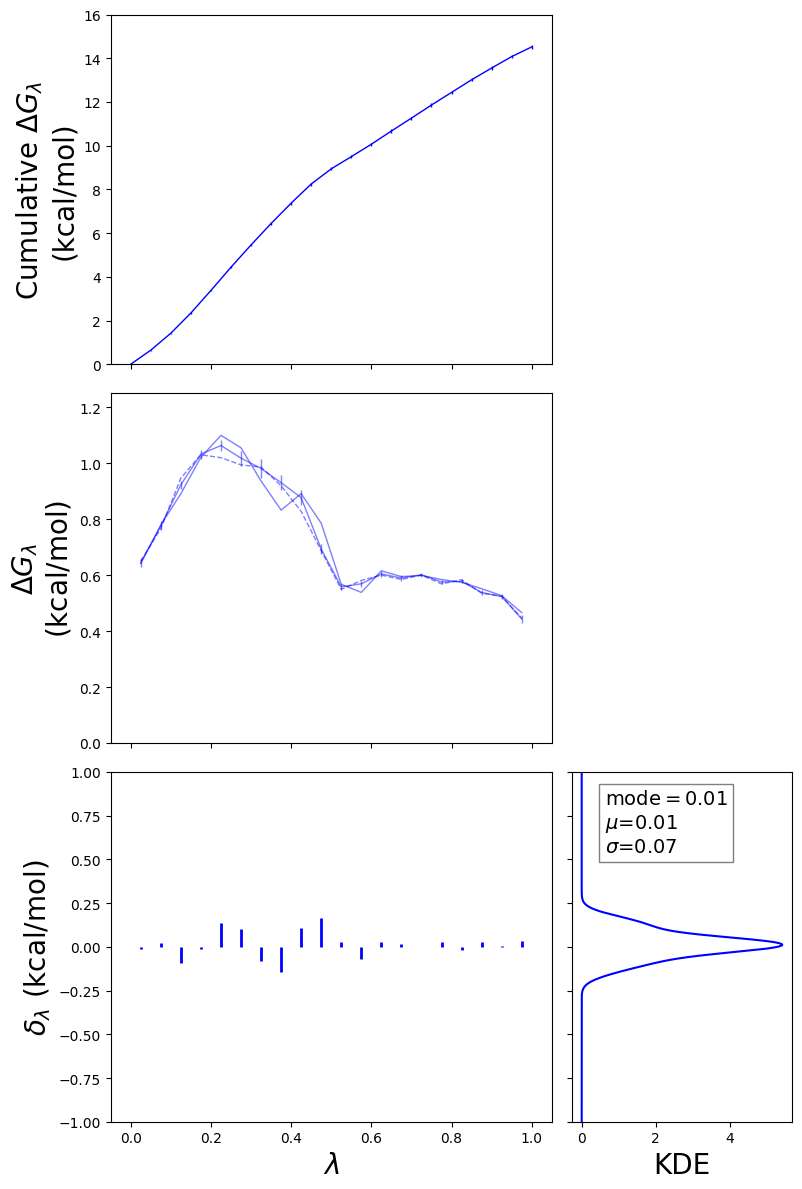

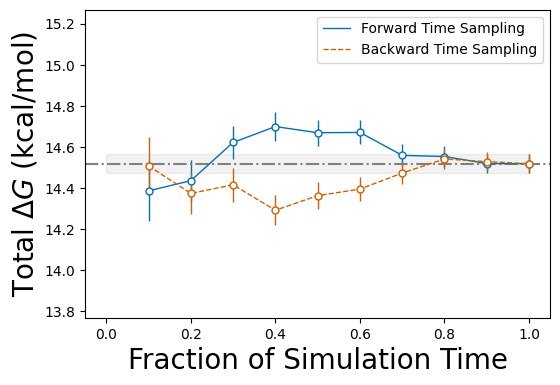

In [7]:
# Make some general plots

# User plot settings
WIDTH = 8
HEIGHT = 4
CUMULATIVE_YLIM = (0, 16)
PERWINDOW_YLIM = (0, 1.25)
FONTSIZE = 20
GENERAL_PLOT_PATH = f"{root}/test_output_notebook_plots/bound_generalFigures.pdf"
CONVERGENCE_PLOT_PATH = f"{root}/test_output_notebook_plots/bound_convergence.pdf"

# Make general delta g plots
fig, axes = safep.plot_general(
            bound_cumulative_data,
            CUMULATIVE_YLIM,
            bound_per_window_data,
            PERWINDOW_YLIM,
            RT,
            WIDTH,
            HEIGHT,
            "KDE",
            fontsize=FONTSIZE,
            )

fig.savefig(GENERAL_PLOT_PATH)
plt.show()

# Make convergence plots
fig2, conv_ax = plt.subplots(1, 1)
conv_ax = safep.convergence_plot(
          conv_ax,
          forward * RT,
          forward_error * RT,
          backward * RT,
          backward_error * RT,
          fontsize=FONTSIZE,
          )

fig2.set_figwidth(WIDTH * (3 / 4))
fig2.set_figheight(HEIGHT)

fig2.savefig(CONVERGENCE_PLOT_PATH)
plt.show()

***
<a id='DBC_TI'></a>
# Process the DBC TI calculation
Compute the free energy cost of restraining the DBC coordinate (**Step C**)

Note: The error estimate below is just the standard deviation of the samples. <br>
The BAR errors calculated above are standard errors of the mean.

In [9]:
NAME = "DBC"
LAMBDAS = 41
EQTIME = 1000
FORCE_CONSTANT = 0
TARGET_FORCE_CONSTANT = 200
FORCE_EXPONENT = 6
UPPER_WALLS = DBCWIDTH
NUMBER_OF_STEPS = 300000

# Construct lambda schedule
lambda_schedule = np.linspace(1, 0, LAMBDAS)

# Manually collect harmonic wall parameters into 
# a dictionary (should use make_harmonicWall_from_Colvars 
# instead) 
harmonic_walls = safep.make_harmonicWall(FC=FORCE_CONSTANT,
                                         targetFC=TARGET_FORCE_CONSTANT,
                                         targetFE=FORCE_EXPONENT,
                                         upperWalls=UPPER_WALLS,
                                         targetEQ=EQTIME,
                                         numSteps=NUMBER_OF_STEPS,
                                         name=NAME,
                                         schedule=lambda_schedule,
                                         )

# Filter and processes data inside of a colvars trajectory file
dbc = safep.TI.read_colvars_trajectory(RESTRAINT_PERTURBATION_PATH,
                                       COLVARS_TRAJECTORY_FILEPATTERN,
                                       eqtime=EQTIME,
                                      )

# This is a small hack in case there are extra samples for the last window
lambdas = (dbc.index.values - 1) // harmonic_walls["targetNumSteps"]
lambdas[0] = 0
lambdas[lambdas == LAMBDAS] = LAMBDAS - 1
data_lambdas = np.round([harmonic_walls["schedule"][i] for i in lambdas], 3)
dbc.loc[:, "L"] = data_lambdas
processed_dbc = dbc.iloc[1:]

# Calculate the free energy for each lambda value, 
# aggregate the result, and estimate the error
dbc_per_window, dbc_cumulative = safep.process_TI(processed_dbc,
                                                  harmonic_walls, 
                                                  lambda_schedule,
                                                  )

# Calculate delta G and error
dbc_delta_g = np.round(dbc_cumulative["dG"][1], 1)
dbc_error = np.round(dbc_cumulative["error"][1], 1)

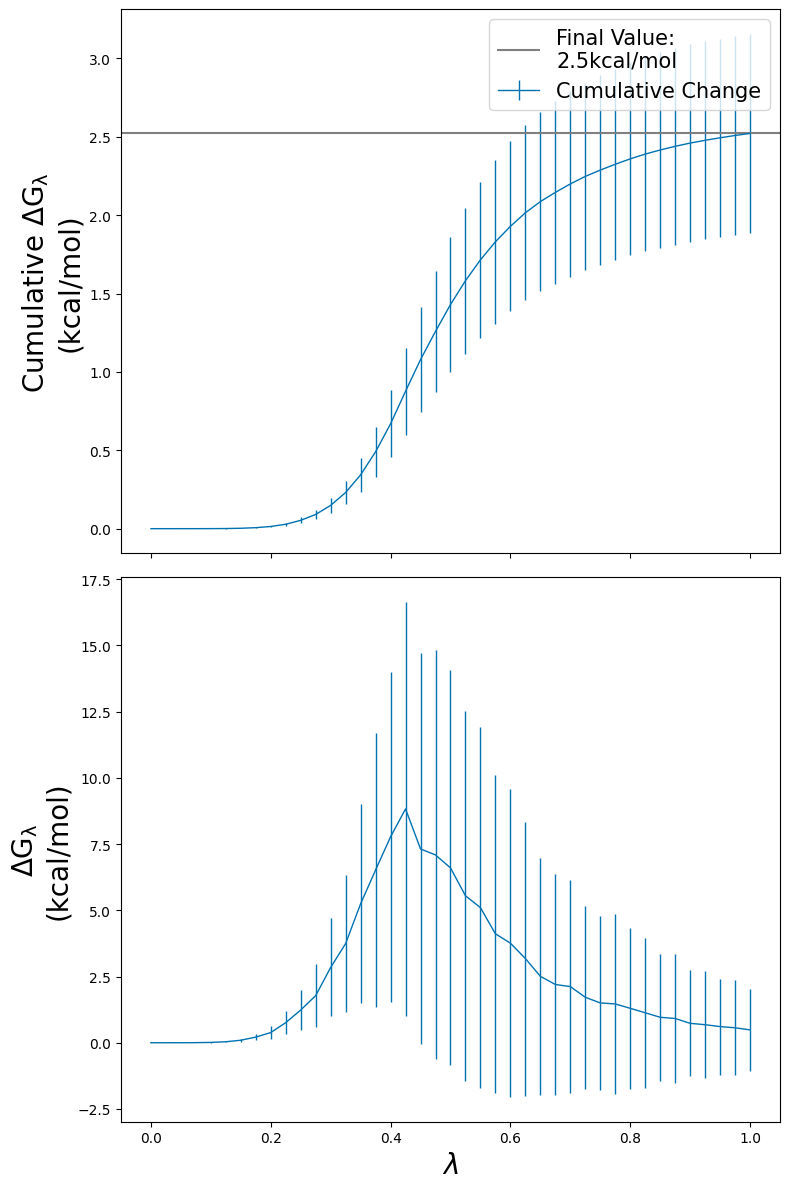

In [10]:
# Make DBC plots
DBC_PLOT_PATH = f"{root}/test_output_notebook_plots/TI_general.pdf"
fig, axes = safep.plot_TI(dbc_cumulative, 
                          dbc_per_window, 
                          fontsize=FONTSIZE
                         )
plt.savefig(DBC_PLOT_PATH)
plt.show()